# 🦷 DentalGemma: Validation & Inference Demo

This notebook demonstrates the capabilities of **[DentalGemma-1.5-4b-it](https://huggingface.co/naazimsnh02/dentalgemma-1.5-4b-it)**, a specialized medical VLM fine-tuned for dental diagnostics.

### 🎯 Core Capabilities validated in this notebook:
1.  **🔍 Cavity Detection**: Identifying carious lesions in bite-wing/periapical X-rays.
2.  **🏥 Pathology Classification**: Analyzing OPGs for cysts, tumors, and bone loss.
3.  **🦷 Tooth Counting**: Automating tooth charting from panoramic images.
4.  **💊 Clinical Assessment**: Generating structured treatment plans from text-based case histories.

---

## 🛠️ 1. Environment Setup

In [1]:
# Uninstall incompatible PyTorch and torchvision versions
!pip uninstall torch torchvision torchaudio

Found existing installation: torch 2.9.0+cu128
Uninstalling torch-2.9.0+cu128:
  Would remove:
    /usr/local/bin/torchfrtrace
    /usr/local/bin/torchrun
    /usr/local/lib/python3.12/dist-packages/functorch/*
    /usr/local/lib/python3.12/dist-packages/torch-2.9.0+cu128.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torch/*
    /usr/local/lib/python3.12/dist-packages/torchgen/*
Proceed (Y/n)? Y
Y
Y
  Successfully uninstalled torch-2.9.0+cu128
Found existing installation: torchvision 0.24.0+cu128
Uninstalling torchvision-0.24.0+cu128:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchvision-0.24.0+cu128.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libcudart.e8e8b82a.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libjpeg.37781fad.so.8
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libnvjpeg.8dd2b5e6.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libpng16.e328d493.so.16
    /usr/loc

In [2]:
# Install compatible PyTorch and torchvision versions
!pip install torch==2.9.0+cu128 torchvision==0.24.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 900.9/900.9 MB 626.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 99.4 MB/s eta 0:00:00


In [3]:
# Install other dependencies
!pip install accelerate bitsandbytes datasets evaluate peft tensorboard transformers trl huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 26.2 MB/s eta 0:00:00


In [5]:
# HF Authentication
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

In [6]:
import os
from huggingface_hub import get_token

# 1. Check if the env var is injected
if "HF_TOKEN" in os.environ:
    print("✅ Success! 'HF_TOKEN' environment variable is present.")
    print(f"Token starts with: {os.environ['HF_TOKEN'][:4]}****")
else:
    print("❌ 'HF_TOKEN' environment variable is MISSING.")

# 2. Check what Hugging Face sees
token = get_token()
if token:
    print(f"✅ Hugging Face Login Status: Authenticated (Token found)")
else:
    print("❌ Hugging Face Login Status: Not Logged In")

✅ Success! 'HF_TOKEN' environment variable is present.
Token starts with: hf_u****
✅ Hugging Face Login Status: Authenticated (Token found)


## 🤖 2. Load Model
Loading the fine-tuned adapter merged with the MedGemma 1.5 4B base model.

In [7]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "naazimsnh02/dentalgemma-1.5-4b-it"

print(f"⏳ Loading model: {MODEL_ID}...")

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32
print(f"Using device: {device.upper()} ({dtype})")

# Load Processor & Model
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto"
)

print("✅ Model loaded successfully!")

⏳ Loading model: naazimsnh02/dentalgemma-1.5-4b-it...
Using device: CUDA (torch.bfloat16)


processor_config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.76k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/884 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

✅ Model loaded successfully!


In [8]:
# Helper Functions
from PIL import Image
import requests
from io import BytesIO
import time
from IPython.display import display, Markdown
import sys

def load_image(image_source):
    """Loads an image from a file path, uploaded file object, or URL."""
    # Handle uploaded file objects (from ipywidgets FileUpload)
    if hasattr(image_source, 'read'):
        return Image.open(image_source).convert("RGB")

    # Handle file paths
    if isinstance(image_source, str):
        if image_source.startswith(('http://', 'https://')):
            response = requests.get(image_source, timeout=10)
            response.raise_for_status()
            return Image.open(BytesIO(response.content)).convert("RGB")
        else:
            return Image.open(image_source).convert("RGB")

    # Handle PIL Image objects directly
    if isinstance(image_source, Image.Image):
        return image_source.convert("RGB")

    raise ValueError(f"Unsupported image source type: {type(image_source)}")

def generate_response(prompt, image=None, max_new_tokens=512):
    """Runs inference on the model with optional image input."""

    # Construct messages
    messages = [
        {"role": "system", "content": [{"type": "text", "text": "You are an expert dental clinician and radiologist AI assistant."}]},
    ]

    user_content = [{"type": "text", "text": prompt}]
    if image:
        user_content.append({"type": "image", "image": image})

    messages.append({"role": "user", "content": user_content})

    # Prepare inputs
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)

    # Measure inference time
    start = time.time()
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # Deterministic for validation
        )
    latency = time.time() - start

    # Decode
    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    response_text = processor.decode(generated_ids, skip_special_tokens=True)

    return response_text, latency

def display_result(title, prompt, response, image=None, latency=0):
    """Prettifies the output display"""
    display(Markdown(f"### {title}"))
    if image:
        # Resize for display if too large
        w, h = image.size
        aspect = h / w
        display_w = min(w, 600)
        display_h = int(display_w * aspect)
        display(image.resize((display_w, display_h)))

    display(Markdown(f"**❓ Query:** {prompt}"))
    display(Markdown(f"**🤖 Model Analysis:**\n\n{response}"))
    display(Markdown(f"*⏱️ Inference Time: {latency:.2f}s*"))
    display(Markdown("---"))

def upload_image():
    """Universal image upload function that works in Colab, Kaggle, and Modal."""

    # Detect environment
    in_colab = 'google.colab' in sys.modules
    in_kaggle = 'kaggle_secrets' in sys.modules or '/kaggle/' in os.getcwd()

    if in_colab:
        # Google Colab - use files.upload()
        from google.colab import files
        print("📤 Click 'Choose Files' to upload an image...")
        uploaded = files.upload()

        if not uploaded:
            raise ValueError("No file uploaded!")

        # Get the first uploaded file
        filename = list(uploaded.keys())[0]
        return load_image(filename)

    else:
        # Kaggle, Modal, or standard Jupyter - use ipywidgets
        try:
            from ipywidgets import FileUpload, Button, Output, VBox
            from IPython.display import display, clear_output

            # Create upload widget
            uploader = FileUpload(accept='image/*', multiple=False)
            output = Output()

            print("📤 Use the upload button below to select an image:")
            display(uploader)
            display(output)

            # Wait for upload
            import time
            timeout = 300  # 5 minutes
            start_time = time.time()

            while not uploader.value:
                time.sleep(0.5)
                if time.time() - start_time > timeout:
                    raise TimeoutError("Upload timeout - no file selected within 5 minutes")

            # Get uploaded file
            uploaded_file = list(uploader.value.values())[0]
            image = Image.open(BytesIO(uploaded_file['content'])).convert("RGB")

            with output:
                clear_output()
                print(f"✅ Uploaded: {uploaded_file['metadata']['name']}")

            return image

        except ImportError:
            # Fallback: manual file path input
            print("⚠️ ipywidgets not available. Please upload your image manually.")
            print("📁 Place your image in the notebook directory and enter the filename:")
            filename = input("Filename: ")
            return load_image(filename)

print("✅ Helper functions loaded!")


✅ Helper functions loaded!


## 🧪 3. Validation Tests

We will run 4 diverse scenarios covering the model's primary use cases.

🦷 Test 1: X-Ray Analysis

📸 Please upload an intraoral X-ray image
   Recommended: Bitewing or periapical radiograph

📤 Click 'Choose Files' to upload an image...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Saving dental_xray.jpg to dental_xray.jpg

🤖 Running inference...


### X-Ray Analysis

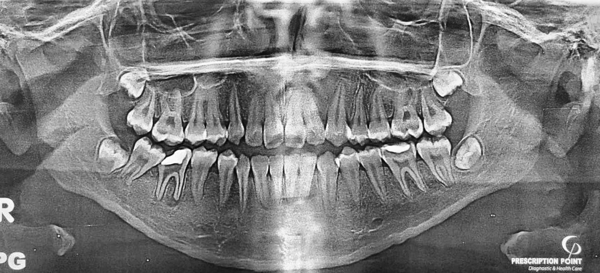

**❓ Query:** Analyze this dental radiograph. Describe any pathological findings and their locations. Provide your assessment of the condition, possible differential diagnoses, and clinical recommendations.

**🤖 Model Analysis:**

This dental X-ray demonstrates the following findings:
  1. In the right maxillary region: radiolucent areas at the root apex consistent with periapical abscess.
  2. In the left maxillary region: a crack or fracture compromising tooth integrity.
  3. In the anterior maxillary region: evidence of periapical infection requiring clinical attention.
  4. In the right mandibular region: radiolucent areas at the root apex consistent with periapical abscess.
  5. In the anterior mandibular region: radiolucent areas at the root apex consistent with periapical abscess.
  6. In the left mandibular region: radiolucent areas at the root apex consistent with periapical abscess.
  7. In the left mandibular region: a crack or fracture compromising tooth integrity.
Prompt clinical assessment is recommended given the infectious nature of the findings.
Urgent clinical evaluation and appropriate antibiotic therapy is recommended.

*⏱️ Inference Time: 19.83s*

---

In [9]:
# Test 1: X-Ray Analysis

print("🦷 Test 1: X-Ray Analysis")
print("=" * 50)
print("\n📸 Please upload an intraoral X-ray image")
print("   Recommended: Bitewing or periapical radiograph\n")

# Upload custom image
image_1 = upload_image()

prompt_1 = "Analyze this dental radiograph. Describe any pathological findings and their locations. Provide your assessment of the condition, possible differential diagnoses, and clinical recommendations."

print("\n🤖 Running inference...")
response_1, time_1 = generate_response(prompt_1, image=image_1)

display_result("X-Ray Analysis", prompt_1, response_1, image_1, time_1)

🦷 Test 2: Panoramic X-ray Analysis

📸 Please upload a panoramic (OPG) X-ray image
   Recommended: Full mouth panoramic radiograph

📤 Click 'Choose Files' to upload an image...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Saving 113_jpg.rf.519d6abdf8b6393a8c905410adb37ca4.jpg to 113_jpg.rf.519d6abdf8b6393a8c905410adb37ca4.jpg

🤖 Running inference...


### Panoramic Analysis

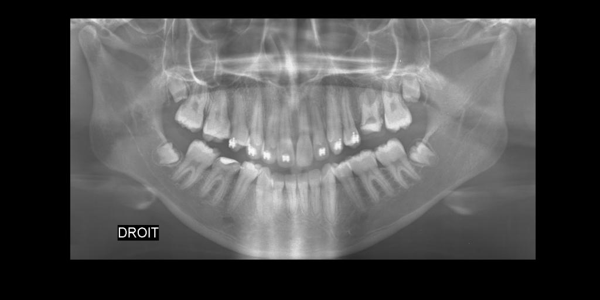

**❓ Query:** This is a panoramic dental X-ray. Identify any noticeable pathologies or abnormalities.

**🤖 Model Analysis:**

This panoramic dental radiograph displays tooth impaction with potential impact on adjacent structures. The extent of involvement suggests moderate severity requiring treatment. Surgical consultation may be warranted depending on patient symptoms. Treatment planning should consider the patient's age and symptomatology.

*⏱️ Inference Time: 8.29s*

---

In [12]:
# Test 2: Panoramic Pathology (OPG)

print("🦷 Test 2: Panoramic X-ray Analysis")
print("=" * 50)
print("\n📸 Please upload a panoramic (OPG) X-ray image")
print("   Recommended: Full mouth panoramic radiograph\n")

# Upload custom image
image_2 = upload_image()

prompt_2 = "This is a panoramic dental X-ray. Identify any noticeable pathologies or abnormalities."

print("\n🤖 Running inference...")
response_2, time_2 = generate_response(prompt_2, image=image_2)

display_result("Panoramic Analysis", prompt_2, response_2, image_2, time_2)


📸 Test 3: Clinical Photo Analysis

📸 Please upload a clinical dental photograph
📤 Click 'Choose Files' to upload an image...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Saving dental_photo.jpg to dental_photo.jpg

🤖 Running inference...


### Clinical Photo Analysis

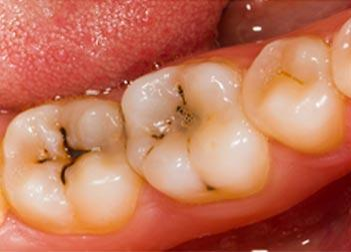

**❓ Query:** Analyze this clinical dental photograph. Describe the condition of the teeth and gums visible. Note any signs of decay, discoloration, or other abnormalities. Assess the severity and recommend follow-up actions.

**🤖 Model Analysis:**

This clinical photograph shows progressive tooth decay with potential pulpal involvement. The extent of involvement suggests moderate severity requiring treatment. The extent of decay should be evaluated to determine appropriate restoration type. A preventive care plan should be established to address risk factors.

*⏱️ Inference Time: 7.83s*

---

In [17]:
# Test 3: Clinical Photo Analysis

print("\n📸 Test 3: Clinical Photo Analysis")
print("=" * 50)
print("\n📸 Please upload a clinical dental photograph")
image_2 = upload_image()

prompt_2 = "Analyze this clinical dental photograph. Describe the condition of the teeth and gums visible. Note any signs of decay, discoloration, or other abnormalities. Assess the severity and recommend follow-up actions."

print("\n🤖 Running inference...")
response_2, time_2 = generate_response(prompt_2, image=image_2)

display_result("Clinical Photo Analysis", prompt_2, response_2, image_2, time_2)


In [18]:
# Test 4: Clinical Case Study (Text Only)

print("💊 Test 4: Clinical Case Assessment")
print("=" * 50)

case_text = """
Patient: 45-year-old female
Chief Complaint: "Sharp pain when drinking cold water in the upper right back tooth."
Medical History: Hypertension (controlled), Allergy to Penicillin.
Clinical Findings: Intraoral: Tooth #16 has a defective amalgam restoration with marginal breakdown. Soft Tissue: Healthy. Periodontal: Generalized mild gingivitis.
Radiographic Findings: Periapical radiolucency associated with mesial root of #15 (incidental). #16 shows radiopacity consistent with amalgam, no periapical pathology.
"""

print("\n📋 Case Details:")
print(case_text)

prompt_3 = f"Based on the clinical history below, provide a differential diagnosis and recommended treatment plan.\n\n{case_text}"

print("\n🤖 Running inference...")
response_3, time_3 = generate_response(prompt_3, image=None)

display_result("Clinical Case Assessment", "(See Case Text above)", response_3, None, time_3)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


💊 Test 4: Clinical Case Assessment

📋 Case Details:

Patient: 45-year-old female
Chief Complaint: "Sharp pain when drinking cold water in the upper right back tooth."
Medical History: Hypertension (controlled), Allergy to Penicillin.
Clinical Findings: Intraoral: Tooth #16 has a defective amalgam restoration with marginal breakdown. Soft Tissue: Healthy. Periodontal: Generalized mild gingivitis.
Radiographic Findings: Periapical radiolucency associated with mesial root of #15 (incidental). #16 shows radiopacity consistent with amalgam, no periapical pathology.


🤖 Running inference...


### Clinical Case Assessment

**❓ Query:** (See Case Text above)

**🤖 Model Analysis:**

## Patient Assessment



**Patient Risk Factors:**
*   Age: 45 years old
*   Symptom: Sharp pain when drinking cold water
*   Clinical Finding: Tooth #16 has a defective amalgam restoration with marginal breakdown.
*   Radiographic Finding: Periapical radiolucency associated with mesial root of #15 (incidental).

**Differential Diagnosis:**
1.  **Defective amalgam restoration with marginal breakdown:** High suspicion given clinical presentation.
2.  **Dental infection with periapical abscess:** Moderate suspicion, consider if systemic signs.
3.  **Direct tooth pulp involvement:** Low suspicion, consider only if other options ruled out.
4.  **Thermal sensitivity:** High suspicion, consider as primary diagnosis.
5.  **Broken down crown or root:** Moderate suspicion, consider if extensive restoration.

**Diagnosis:**
*   **Primary:** Tooth #16 has a defective amalgam restoration with marginal breakdown.
*   **Secondary:** Thermal sensitivity.
*   **Tertiary:** Dental infection with periapical abscess.
*   **Quaternary:** Direct tooth pulp involvement.
*   **Quinary:** Broken down crown or root.

**Treatment Plan:**
1. **Defective amalgam restoration with marginal breakdown:**
   *   **Treatment:** Complete coronal reduction and re-crown preparation.
   *   **Rationale:** The extent of decay requires more tooth structure removal.
   *   **Recommendation:** Full coronal reduction and re-crown preparation.
2. **Thermal sensitivity:**
   *   **Treatment:** Topical anesthetic gel application.
   *   **Rationale:** Manage symptoms until definitive restoration.
   *   **Recommendation:** Apply topical anesthetic gel as needed.
3. **Dental infection with periapical abscess:**
   *   **Treatment:** Endodontic access and drainage.
   *   **Rationale:** Systemic implications must be evaluated.
   *   **Recommendation:** Urgent consultation for periapical drainage.
4. **Direct tooth pulp involvement:**
   *   **Treatment:** Pulpotomy or pulpectomy.
   *   **Rationale:** Preserve remaining tooth structure.
   *   **Recommendation:** Perform pulpotomy or pulpectomy based on vital status.
5. **Broken down crown or root:**
   *   **Treatment:** Crown-root ratio assessment.
   *   **Rationale:** Prognosis depends on remaining support.


*⏱️ Inference Time: 39.38s*

---

## 📊 4. Performance Benchmarking
Running a quick loop to estimate average inference latency for a standard cavity detection task.

In [11]:
import numpy as np

print("🚀 Running 5 iterations for benchmarking...")
latencies = []

for i in range(5):
    _, t = generate_response(
        "Check for cavities.",
        image=image_1,
        max_new_tokens=128
    )
    latencies.append(t)
    print(f"Run {i+1}: {t:.4f}s")

avg_lat = np.mean(latencies)
print(f"\n⚡ Average Latency: {avg_lat:.4f}s")
print(f"Peak Memory: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB" if torch.cuda.is_available() else "Memory: N/A")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🚀 Running 5 iterations for benchmarking...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 1: 8.1515s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 2: 8.6650s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 3: 9.9030s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 4: 9.3160s
Run 5: 8.3226s

⚡ Average Latency: 8.8716s
Peak Memory: 11.66 GB
